<a href="https://colab.research.google.com/github/Janardan-thapaliya/Deep_Learning_SNN/blob/main/SNN_Caltech101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

# Replace with your actual file name & path in Drive
zip_path = '/content/drive/MyDrive/Dataset/Caltech101.zip'
extract_to = '/content/dataset'  # Extract into Colab's temporary space

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Optional: List the extracted files
os.listdir(extract_to)

['Caltech101']

In [3]:
with zipfile.ZipFile("/content/Caltech101_annotations.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [4]:
pip install snntorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 6.2 MB/s eta 0:00:00


In [5]:
import os

# Dataset paths
dataset_path = "/content/dataset/Caltech101"
annotation_path = "/content/dataset/Caltech101_annotations"

# Print number of classes and example files
def explore_dataset(base_path):
    classes = sorted(os.listdir(base_path))
    print(f"Total classes found: {len(classes)}\n")
    for cls in classes[:5]:  # show just first 5 classes
        class_path = os.path.join(base_path, cls)
        files = os.listdir(class_path)
        print(f"Class: {cls}, Samples: {len(files)}, First sample: {files[0]}")

explore_dataset(dataset_path)
explore_dataset(annotation_path)


Total classes found: 101

Class: BACKGROUND_Google, Samples: 467, First sample: image_0267.bin
Class: Faces_easy, Samples: 435, First sample: image_0267.bin
Class: Leopards, Samples: 200, First sample: image_0036.bin
Class: Motorbikes, Samples: 798, First sample: image_0575.bin
Class: accordion, Samples: 55, First sample: image_0036.bin
Total classes found: 100

Class: Faces_easy, Samples: 435, First sample: annotation_0323.bin
Class: Leopards, Samples: 200, First sample: annotation_0091.bin
Class: Motorbikes, Samples: 798, First sample: annotation_0323.bin
Class: accordion, Samples: 55, First sample: annotation_0002.bin
Class: airplanes, Samples: 800, First sample: annotation_0323.bin


In [6]:
def read_Ncaltech_file(file_path):
    x_coords, y_coords, polarities, timestamps = [], [], [], []
    with open(file_path, 'rb') as f:
        data = f.read()
        for i in range(0, len(data), 5):
            event = int.from_bytes(data[i:i+5], byteorder='big')
            x_coords.append((event >> 32) & 0xFF)
            y_coords.append((event >> 24) & 0xFF)
            polarities.append((event >> 23) & 0x01)
            timestamps.append(event & 0x7FFFFF)
    return x_coords, y_coords, polarities, timestamps

file_path = "/content/dataset/Caltech101/Motorbikes/image_0001.bin"
x, y, p, t = read_Ncaltech_file(file_path)

print(f"Events Loaded: {len(x)}")
print(f"x: {x[:10]}")
print(f"y: {y[:10]}")
print(f"polarity: {p[:10]}")
print(f"time: {t[:10]}")

Events Loaded: 128158
x: [216, 27, 88, 136, 100, 222, 58, 61, 230, 25]
y: [93, 86, 85, 71, 1, 49, 85, 120, 56, 82]
polarity: [1, 0, 0, 1, 0, 1, 1, 0, 1, 1]
time: [11, 12, 36, 50, 64, 77, 98, 126, 145, 186]


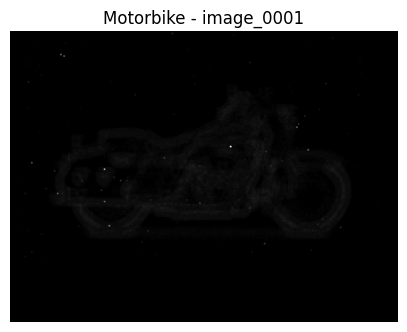

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_events(x, y, p, title="Event Frame"):
    img = np.zeros((180, 240))  # standard resolution
    for i in range(len(x)):
        img[y[i], x[i]] += 1 if p[i] == 1 else 0

    plt.figure(figsize=(5, 4))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_events(x, y, p, title="Motorbike - image_0001")


In [8]:
anno_path = "/content/dataset/Caltech101_annotations/Motorbikes/annotation_0001.bin"
xa, ya, pa, ta = read_Ncaltech_file(anno_path)

print(f"Annotation Events Loaded: {len(xa)}")
print(f"x: {xa[:10]}")
print(f"y: {ya[:10]}")
print(f"polarity: {pa[:10]}")
print(f"time: {ta[:10]}")

Annotation Events Loaded: 61
x: [2, 0, 14, 0, 24, 0, 83, 0, 206, 0]
y: [0, 14, 0, 24, 0, 69, 0, 203, 0, 109]
polarity: [0, 0, 1, 0, 0, 0, 1, 0, 0, 0]
time: [327704, 52736, 5111931, 31488, 917506, 52224, 4653139, 22784, 6619339, 49920]


In [32]:
pip install spikingjelly torch torchvision matplotlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [24]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from spikingjelly.clock_driven import neuron, surrogate, functional
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------
# 🔹 Dataset Handler (Native Events)
# -----------------------------
class NCaltech101Dataset(Dataset):
    def __init__(self, data_dir, annotation_dir, classes, time_window=10000):
        self.data_dir = data_dir
        self.annotation_dir = annotation_dir
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []

        for cls in classes:
            class_dir = os.path.join(data_dir, cls)
            annotation_class_dir = os.path.join(annotation_dir, cls)
            for f in os.listdir(class_dir):
                if f.endswith('.bin'):
                    self.samples.append((
                        os.path.join(class_dir, f),
                        os.path.join(annotation_class_dir, f.replace('image', 'annotation')),
                        self.class_to_idx[cls]
                    ))

        self.time_window = time_window

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ann_path, label = self.samples[idx]

        events = np.fromfile(img_path, dtype=np.uint8).reshape(-1, 5)
        x, y, t, p = events[:, 0], events[:, 1], events[:, 2].astype(np.int32), events[:, 3]

        # Normalize time and bin events
        t = t - t.min()
        frames = np.zeros((self.time_window, 180, 240))  # Assuming resolution

        for xi, yi, ti in zip(x, y, t):
            if ti < self.time_window:
                frames[ti, yi, xi] += 1

        frames = torch.tensor(frames, dtype=torch.float32).clamp(0, 1)
        return frames.unsqueeze(1), label  # [T, 1, H, W]

# -----------------------------
# 🔹 Spiking YOLO-ish SNN Model
# -----------------------------
class SNNDetector(nn.Module):
    def __init__(self, num_classes, time_window):
        super().__init__()
        self.time_window = time_window
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.pool2 = nn.MaxPool2d(2)

        self.fc = nn.Linear(32 * 45 * 60, num_classes)  # 180x240 -> 90x120 -> 45x60

    def forward(self, x):  # x: [T, B, C, H, W]
        functional.reset_net(self)

        batch_size = x.shape[1]
        out_spikes = 0

        for t in range(self.time_window):
            out = self.conv1(x[t])
            out = self.lif1(out)
            out = self.pool1(out)

            out = self.conv2(out)
            out = self.lif2(out)
            out = self.pool2(out)

            out = out.view(batch_size, -1)
            out_spikes += self.fc(out)

        return out_spikes / self.time_window  # Avg spikes

# -----------------------------
# 🔹 Training + Evaluation
# -----------------------------
def train(model, loader, optimizer, loss_fn, device):
    model.train()
    for x, y in tqdm(loader, desc="Training"):
        x, y = x.to(device), y.to(device)
        x = x.permute(1, 0, 2, 3, 4)  # [B, T, C, H, W] -> [T, B, C, H, W]
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

def evaluate(model, loader, device, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating"):
            x = x.to(device).permute(1, 0, 2, 3, 4)
            y = y.to(device)
            out = model(x)
            pred = out.argmax(1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=90)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 🔹 Main
# -----------------------------
if __name__ == "__main__":
    # Config
    DATASET_PATH = "/content/dataset/Caltech101"
    ANNOTATION_PATH = "/content/dataset/Caltech101_annotations"
    CLASSES = sorted(os.listdir(DATASET_PATH))
    EPOCHS = 5
    TIME_WINDOW = 50
    BATCH_SIZE = 4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dataset + Loader
    train_ds = NCaltech101Dataset(DATASET_PATH, ANNOTATION_PATH, CLASSES, TIME_WINDOW)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # Model
    model = SNNDetector(num_classes=len(CLASSES), time_window=TIME_WINDOW).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    # Training Loop
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        train(model, train_loader, optimizer, loss_fn, DEVICE)

    # Evaluation + Confusion Matrix
    evaluate(model, train_loader, DEVICE, CLASSES)


In [2]:
# 🔸 Save model after training
torch.save(model.state_dict(), "snn_detector_ncaltech101.pth")
print("✅ Model saved as snn_detector_ncaltech101.pth")

✅ Model saved as snn_detector_ncaltech101.pth


In [3]:
from torch.utils.data import random_split

# Split 80-20 train/test
train_len = int(len(train_ds) * 0.8)
test_len = len(train_ds) - train_len
train_subset, test_subset = random_split(train_ds, [train_len, test_len])

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)  # batch=1 for prediction

In [4]:
def predict_sample(model, sample, class_names, device, top_k=5):
    model.eval()
    x, label = sample
    x = x.unsqueeze(1).to(device)  # [T, 1, C, H, W]
    x = x.permute(1, 0, 2, 3, 4)   # [T, B, C, H, W]

    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)
        top_probs, top_classes = probs.topk(top_k, dim=1)

        print("\n🎯 Prediction:")
        for i in range(top_k):
            cls = class_names[top_classes[0][i]]
            prob = top_probs[0][i].item()
            print(f"  {i+1}. {cls:20s}  —  {prob:.4f}")

        print(f"\n✅ Ground Truth: {class_names[label]}")

In [13]:
def predict_sample(model, sample, class_names, device, top_k=5):
    model.eval()
    x, label = sample  # x: [T, C, H, W]

    # Convert to [T, B, C, H, W] for model (B=1)
    x = x.unsqueeze(1).to(device)  # [T, 1, C, H, W]

    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)
        top_probs, top_classes = probs.topk(top_k, dim=1)

        print("\n Prediction:")
        for i in range(top_k):
            cls = class_names[top_classes[0][i]]
            prob = top_probs[0][i].item()
            print(f"  {i+1}. {cls:20s}  —  {prob:.4f}")

        print(f"\n Ground Truth: {class_names[label]}")


In [14]:
#  Load model (if needed)
# model.load_state_dict(torch.load("snn_detector_ncaltech101.pth"))
# model.to(DEVICE)

# Predict on a few samples from test set
print("\n Predicting some test samples...")
for i in range(10):
    predict_sample(model, test_subset[i], CLASSES, DEVICE)



 Predicting some test samples...

 Prediction:
  1. airplanes             —  0.9877
  2. wrench                —  0.0013
  3. cup                   —  0.0013
  4. gramophone            —  0.0009
  5. electric_guitar       —  0.0008

 Ground Truth: airplanes

 Prediction:
  1. flamingo              —  0.4215
  2. kangaroo              —  0.4023
  3. cougar_body           —  0.0252
  4. ketch                 —  0.0240
  5. panda                 —  0.0228

 Ground Truth: kangaroo

 Prediction:
  1. Motorbikes            —  0.9915
  2. crayfish              —  0.0026
  3. hawksbill             —  0.0021
  4. BACKGROUND_Google     —  0.0019
  5. cannon                —  0.0002

 Ground Truth: Motorbikes

 Prediction:
  1. flamingo              —  0.0996
  2. minaret               —  0.0936
  3. bonsai                —  0.0630
  4. metronome             —  0.0586
  5. panda                 —  0.0458

 Ground Truth: dragonfly

 Prediction:
  1. BACKGROUND_Google     —  0.2844
  2. flamingo  

In [18]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

def evaluate_with_segmented_confusion(model, loader, device, class_names, segment_size=20, show_per_segment=5):
    model.eval()
    y_true, y_pred = [], []
    all_inputs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Running inference"):
            x = x.to(device).permute(1, 0, 2, 3, 4)  # [T, B, C, H, W]
            y = y.to(device)
            out = model(x)
            pred = out.argmax(1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

            x = x.permute(1, 0, 2, 3, 4)  # [B, T, C, H, W]
            all_inputs.extend(x.cpu())

    cm = confusion_matrix(y_true, y_pred)
    total_classes = len(class_names)
    print(f"\n📊 Confusion matrix (100 classes) computed.")

    for seg_start in range(0, total_classes, segment_size):
        seg_end = min(seg_start + segment_size, total_classes)
        labels_segment = class_names[seg_start:seg_end]
        cm_segment = cm[seg_start:seg_end, seg_start:seg_end]

        # 🔷 Display matrix
        print(f"\n📌 Confusion Matrix: Classes {seg_start}–{seg_end-1}")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_segment, display_labels=labels_segment)
        disp.plot(xticks_rotation=90)
        plt.title(f"Confusion Matrix (Classes {seg_start}-{seg_end - 1})")
        plt.tight_layout()
        plt.show()

        # 🖼️ Misclassified image samples
        shown = 0
        print(f"\n🖼️ Showing {show_per_segment} misclassified images from this range...")
        for i in range(len(y_true)):
            true = y_true[i]
            pred = y_pred[i]

            if true != pred and seg_start <= true < seg_end:
                frame = all_inputs[i].sum(dim=0).squeeze().numpy()  # [T, C, H, W] → [H, W]

                plt.imshow(frame, cmap="gray")
                plt.title(f"True: {class_names[true]} | Pred: {class_names[pred]}")
                plt.axis("off")
                plt.show()

                shown += 1
                if shown >= show_per_segment:
                    break


Running inference: 100%|██████████| 1742/1742 [03:03<00:00,  9.52it/s]



📊 Confusion matrix (100 classes) computed.

📌 Confusion Matrix: Classes 0–19


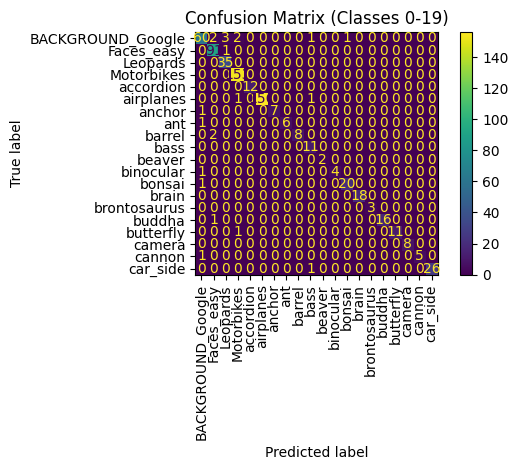


🖼️ Showing 5 misclassified images from this range...


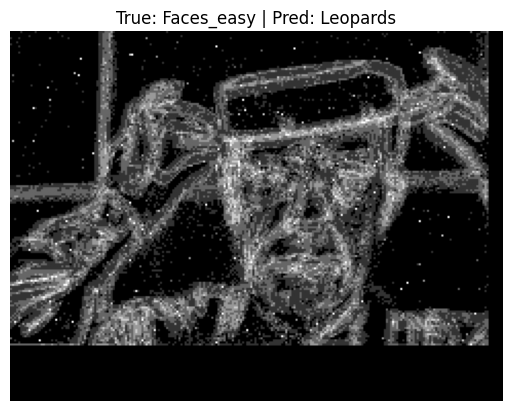

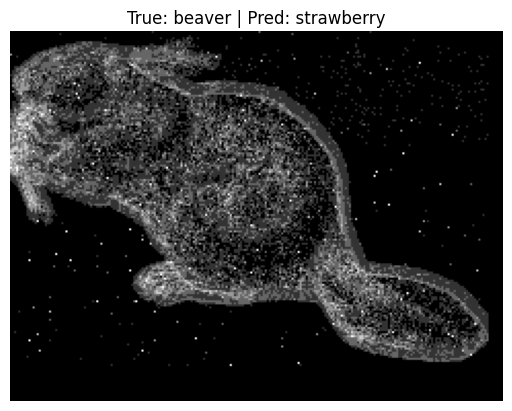

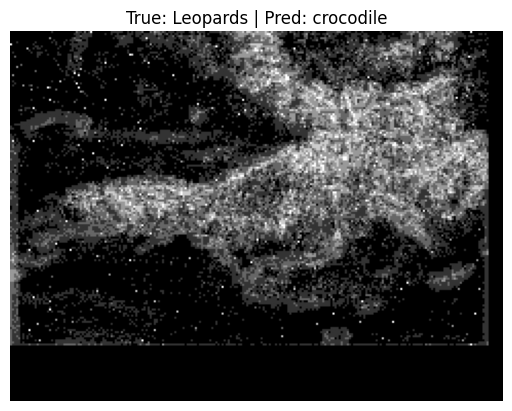

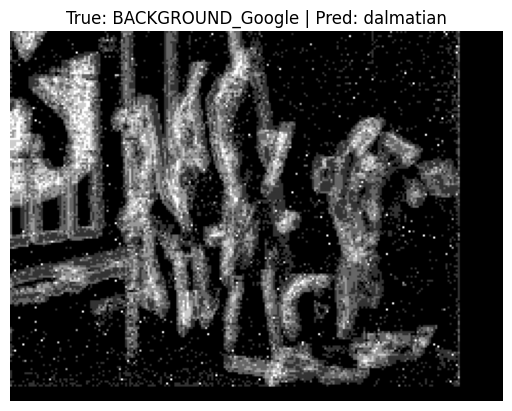

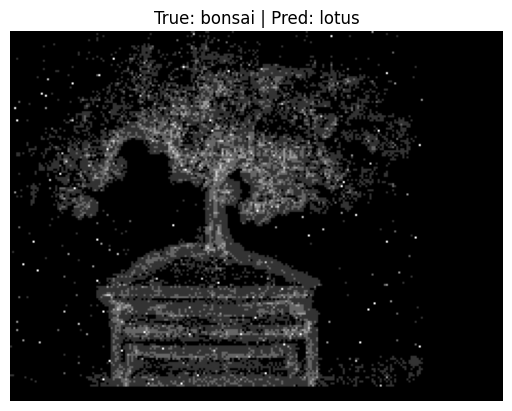


📌 Confusion Matrix: Classes 20–39


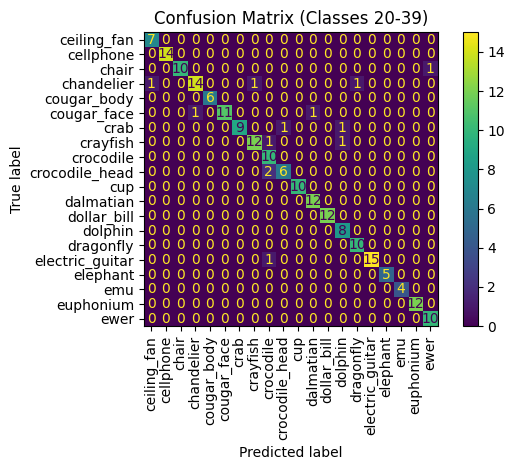


🖼️ Showing 5 misclassified images from this range...


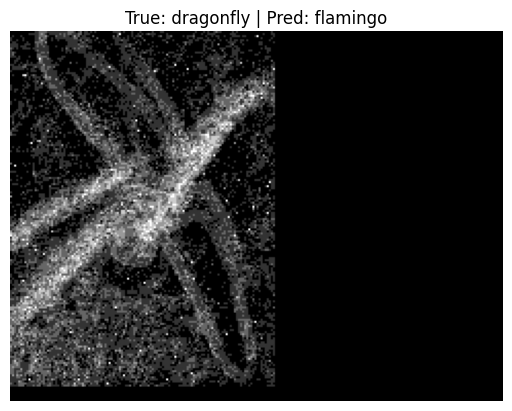

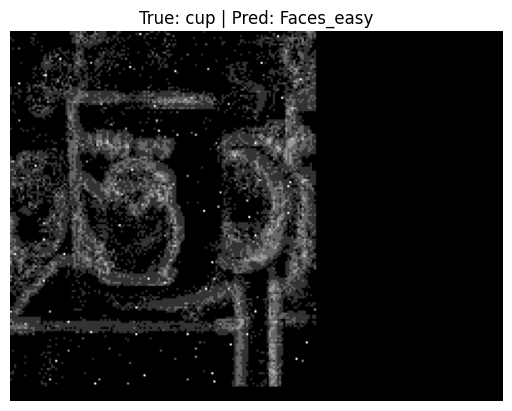

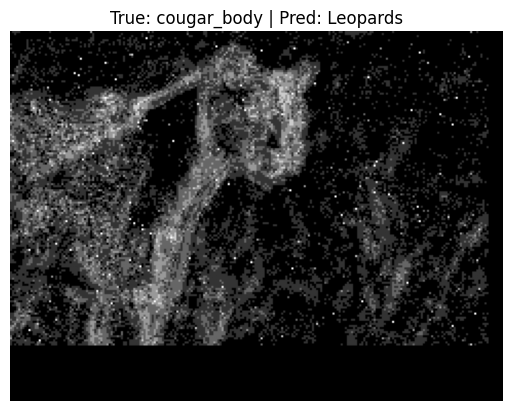

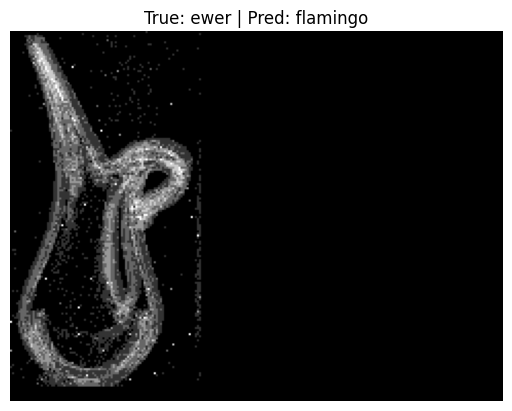

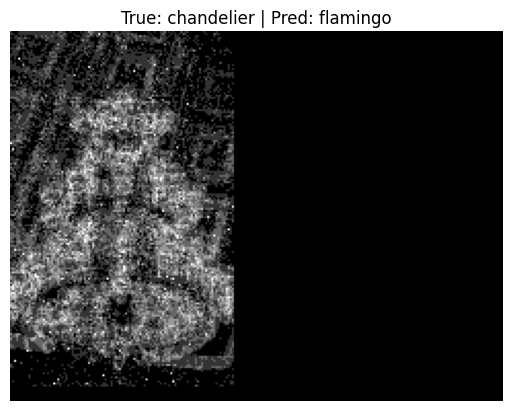


📌 Confusion Matrix: Classes 40–59


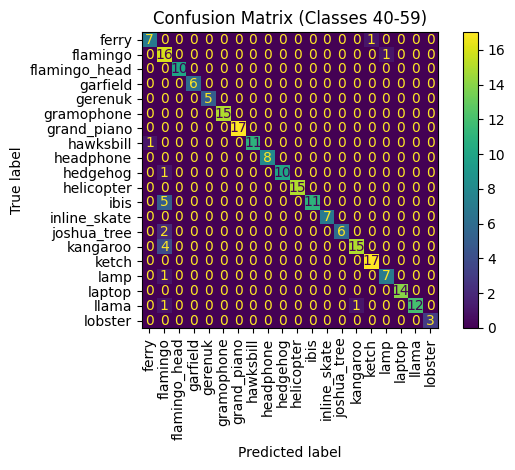


🖼️ Showing 5 misclassified images from this range...


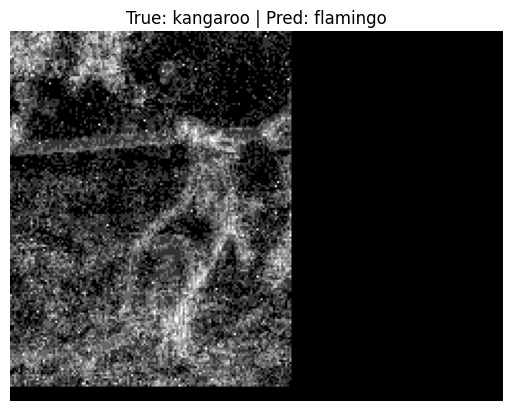

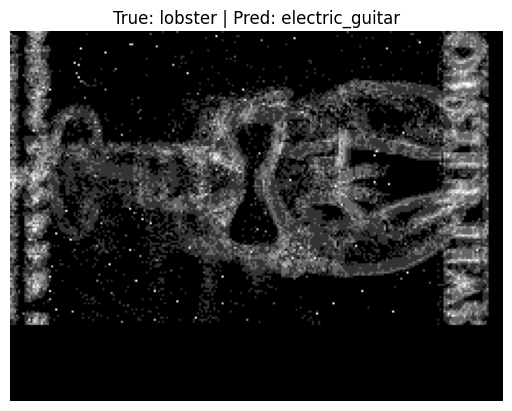

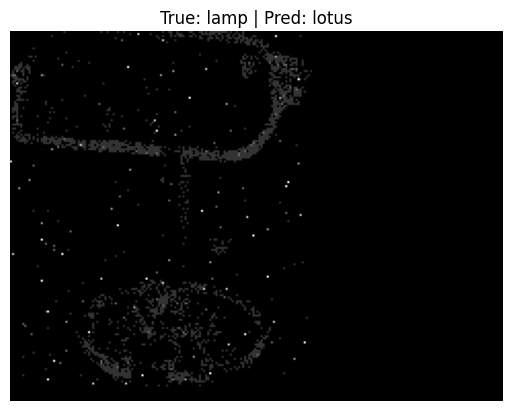

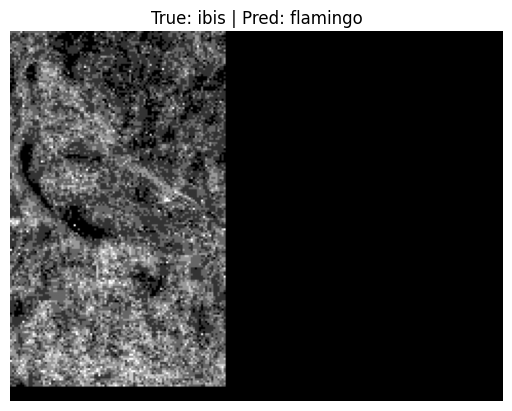

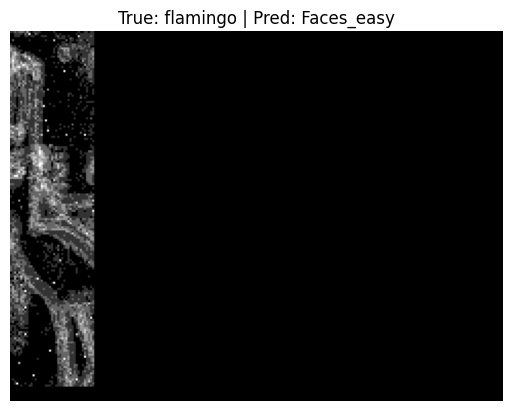


📌 Confusion Matrix: Classes 60–79


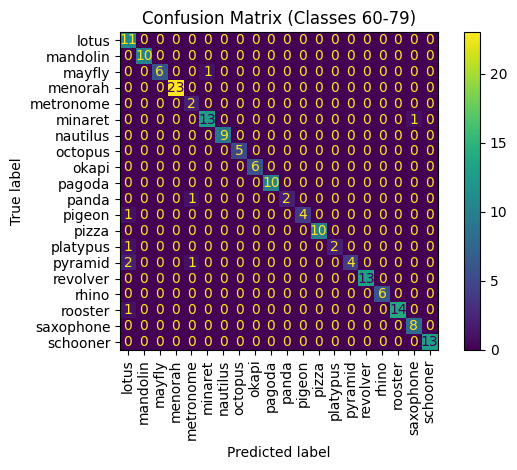


🖼️ Showing 5 misclassified images from this range...


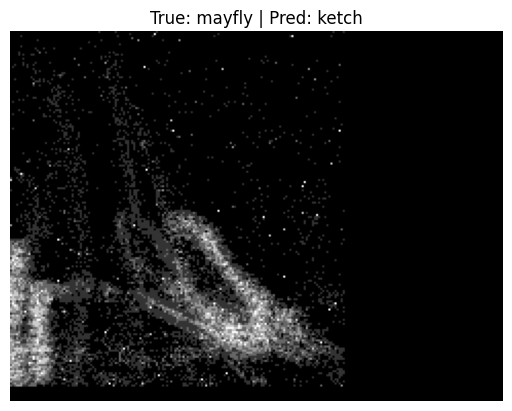

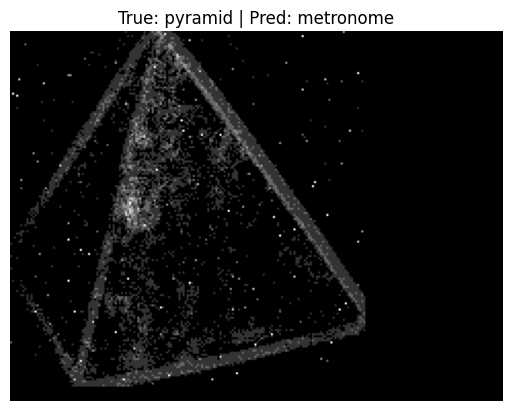

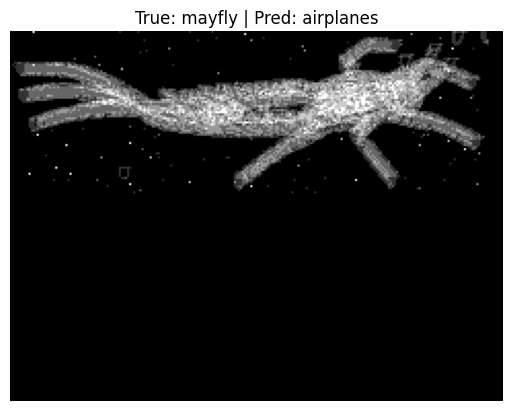

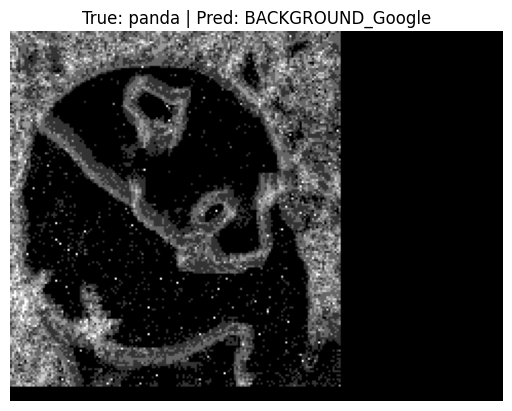

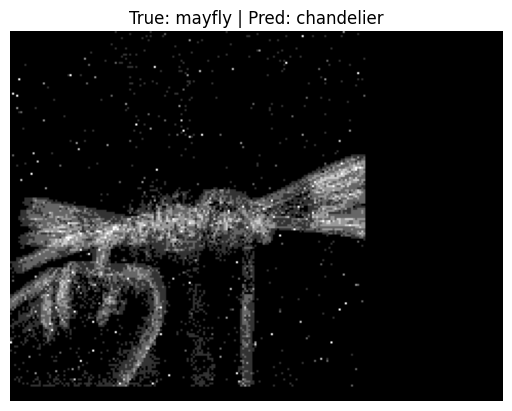


📌 Confusion Matrix: Classes 80–99


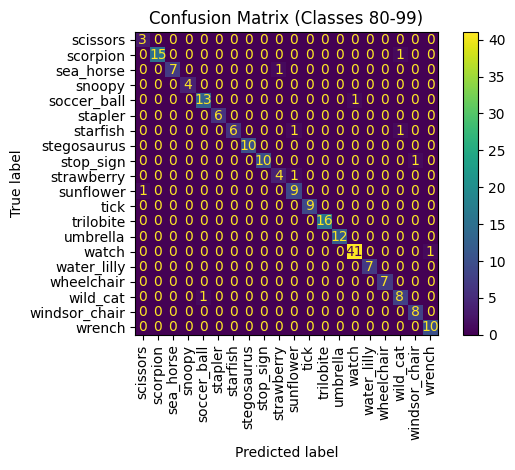


🖼️ Showing 5 misclassified images from this range...


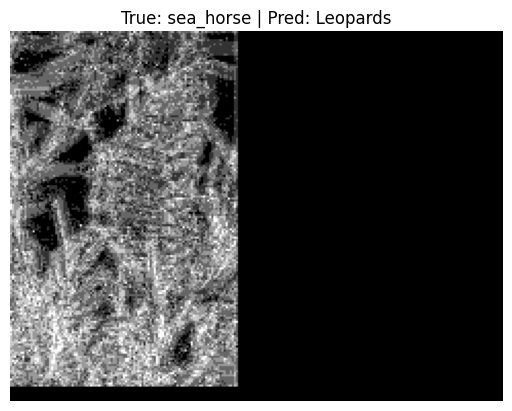

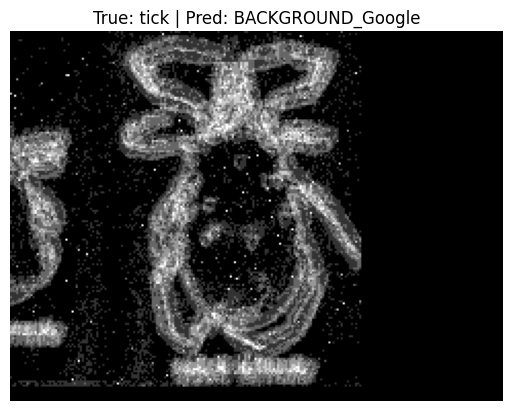

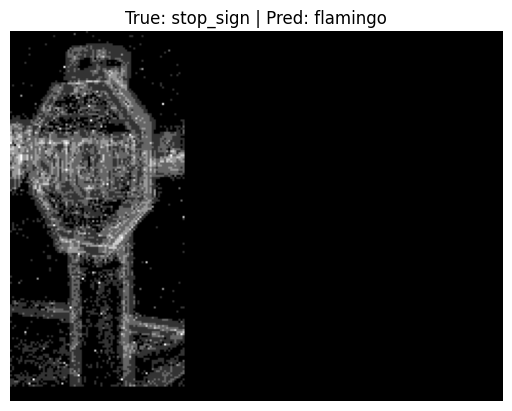

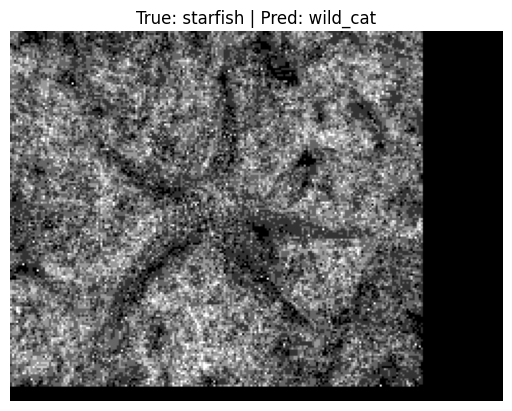

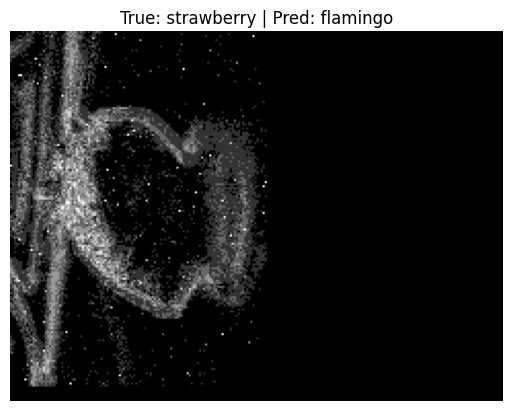


📌 Confusion Matrix: Classes 100–100


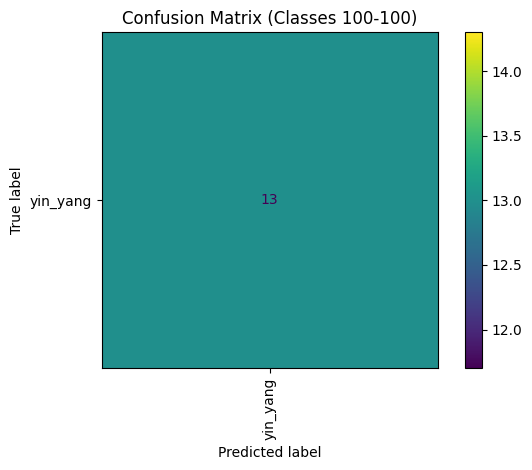


🖼️ Showing 5 misclassified images from this range...


In [19]:
evaluate_with_segmented_confusion(
    model=model,
    loader=test_loader,
    device=DEVICE,
    class_names=CLASSES,
    segment_size=20,         # 5 groups of 20 classes
    show_per_segment=5       # Show 5 misclassifications per group
)

In [20]:
def compute_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Calculating accuracy"):
            x = x.to(device).permute(1, 0, 2, 3, 4)  # [T, B, C, H, W]
            y = y.to(device)

            out = model(x)
            pred = out.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    accuracy = 100 * correct / total
    print(f"\n✅ Accuracy of the model: {accuracy:.2f}%")
    return accuracy
accuracy = compute_accuracy(model, test_loader, DEVICE)


Calculating accuracy: 100%|██████████| 1742/1742 [02:55<00:00,  9.92it/s]


✅ Accuracy of the model: 83.24%


In [21]:
accuracy = compute_accuracy(model, test_loader, DEVICE)

Calculating accuracy: 100%|██████████| 1742/1742 [02:51<00:00, 10.15it/s]


✅ Accuracy of the model: 83.24%
